In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

data downloaded from https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [2]:
import os
inppth = "/kaggle/input/datasets/ryansingh7417/nyc-taxi-trip/"

In [3]:
#january-2025 data
dt = pd.read_parquet(inppth+"yellow_tripdata_2025-01.parquet")

In [4]:
dt.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


* PULocationID TLC Taxi Zone in which the taximeter was engaged.
* DOLocationID TLC Taxi Zone in which the taximeter was disengaged.

In [5]:
dt.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


In [6]:
dt2 = dt[['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount']]
dt2.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,229,237,1,10.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,236,237,1,5.1
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,141,141,1,5.1
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,244,244,2,7.2
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,244,116,2,5.8


In [7]:
# check vendor ID should be 1 2 6 or 7

dt2['VendorID'].unique()

array([1, 2, 7, 6], dtype=int32)

In [8]:
# check passenger count [>0 <6]
# passenger_count capped at 5 per NYC legal maximum is 4 in standard sedans and 5 in minivan cabs. Values of 0 and 6+ are sensor defaults or data errors.

dt2[(dt2['passenger_count']>0) & (dt2['passenger_count']<=6)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,229,237,1,10.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,236,237,1,5.1
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,141,141,1,5.1
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,244,244,2,7.2
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,244,116,2,5.8
...,...,...,...,...,...,...,...,...,...,...
2935072,1,2025-01-31 23:01:14,2025-01-31 23:08:49,1.0,1.50,1.0,163,48,2,8.6
2935073,1,2025-01-31 23:11:28,2025-01-31 23:14:45,1.0,0.60,1.0,48,48,2,5.1
2935074,2,2025-01-31 23:14:32,2025-01-31 23:28:02,1.0,1.96,1.0,142,164,1,14.2
2935075,2,2025-01-31 23:15:51,2025-01-31 23:21:22,2.0,0.89,1.0,230,142,1,7.2


In [9]:
dt2[dt2['passenger_count']==6]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
436,2,2025-01-01 00:19:03,2025-01-01 00:43:37,6.0,3.97,1.0,231,229,1,24.0
861,2,2024-12-31 23:56:19,2025-01-01 00:11:19,6.0,2.28,1.0,68,107,1,14.9
908,2,2025-01-01 00:20:54,2025-01-01 00:38:15,6.0,2.09,1.0,161,114,2,17.0
910,2,2025-01-01 00:50:46,2025-01-01 01:10:02,6.0,1.87,1.0,79,186,1,17.7
1695,2,2025-01-01 00:12:46,2025-01-01 00:18:14,6.0,0.80,1.0,13,88,3,-7.2
...,...,...,...,...,...,...,...,...,...,...
2933207,1,2025-01-31 23:18:43,2025-01-31 23:44:59,6.0,4.50,1.0,142,4,1,26.1
2933496,2,2025-01-31 23:45:50,2025-01-31 23:52:57,6.0,1.40,1.0,230,229,1,9.3
2933752,2,2025-01-31 23:10:00,2025-01-31 23:33:55,6.0,4.22,1.0,249,52,1,24.7
2933753,2,2025-01-31 23:37:20,2025-01-31 23:49:25,6.0,3.02,1.0,52,231,1,16.3


In [10]:
dt2.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
dtype: int64

In [11]:
#dt['fare_amount'] = abs(dt['fare_amount'])

# using absolute value for fare amount assumes there is just sign error. but negative amounts can reperesent refunds, corrections, or other issues

In [12]:
dt2['fare_amount'].describe()

count    3.475226e+06
mean     1.708180e+01
std      4.634729e+02
min     -9.000000e+02
25%      8.600000e+00
50%      1.211000e+01
75%      1.950000e+01
max      8.633721e+05
Name: fare_amount, dtype: float64

max fare_amount in the dataset is 863372, which shows possible error in data recording. kde plot will show distortion even if log1p is used to normalise the values

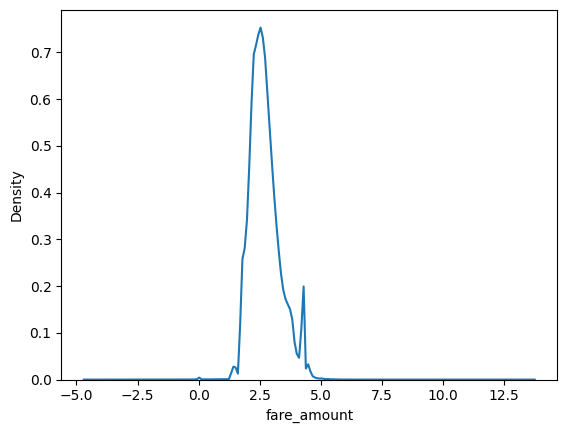

In [13]:
import seaborn as sns

sns.kdeplot(np.log1p(dt2['fare_amount']))
plt.grid(False)
#plt.axvline(50000,0,1,c='black',ls='--')

plt.show()

Lets examine how many negative and zero values are there for fare amount

In [14]:
print(f"number of rows with negative fares: {(dt2['fare_amount']<0).sum()}")

number of rows with negative fares: 144118


In [15]:
print(f"number of rows with 0 fare: {(dt2['fare_amount']==0).sum()}")

number of rows with 0 fare: 1398


Drop zero and negative fare records

In [16]:
dtclean = dt2[dt2['fare_amount']>0].copy()

In [17]:
# passenger cannot be more than 6 as per nyc taxi rules
dtcl = dtclean[(dtclean['passenger_count']>0) & (dtclean['passenger_count']<6)]

# remove fare greater than 500. minimum amount is 2.5, remove 0 fare
dtcl = dtcl[(dtcl['fare_amount']>2.50) & (dtcl['fare_amount']<500)]

In [18]:
dtcl

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,229,237,1,10.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,236,237,1,5.1
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,141,141,1,5.1
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,244,244,2,7.2
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,244,116,2,5.8
...,...,...,...,...,...,...,...,...,...,...
2935072,1,2025-01-31 23:01:14,2025-01-31 23:08:49,1.0,1.50,1.0,163,48,2,8.6
2935073,1,2025-01-31 23:11:28,2025-01-31 23:14:45,1.0,0.60,1.0,48,48,2,5.1
2935074,2,2025-01-31 23:14:32,2025-01-31 23:28:02,1.0,1.96,1.0,142,164,1,14.2
2935075,2,2025-01-31 23:15:51,2025-01-31 23:21:22,2.0,0.89,1.0,230,142,1,7.2


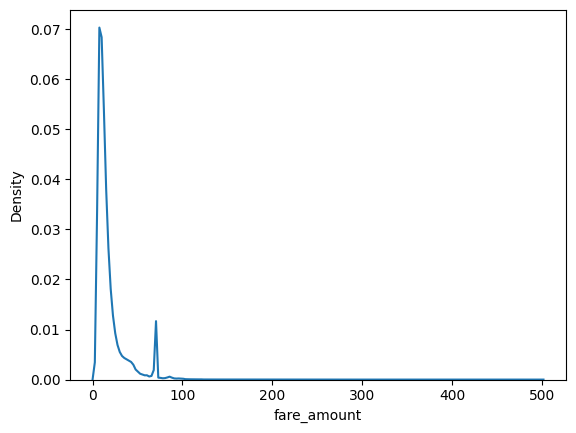

In [19]:
import seaborn as sns

sns.kdeplot(dtcl['fare_amount'])
plt.grid(False)
#plt.axvline(50000,0,1,c='black',ls='--')

plt.show()

In [20]:
dtcl[dtcl['fare_amount']>100]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
823,2,2025-01-01 00:49:36,2025-01-01 02:11:46,4.0,24.70,1.0,68,82,3,111.5
902,2,2025-01-01 00:05:17,2025-01-01 00:54:59,2.0,29.61,3.0,138,265,1,130.8
918,1,2025-01-01 00:35:40,2025-01-01 01:11:54,3.0,29.40,4.0,132,265,2,189.9
1064,2,2025-01-01 00:08:31,2025-01-01 00:46:27,3.0,27.11,4.0,132,265,1,123.4
2221,2,2025-01-01 00:11:07,2025-01-01 00:53:06,1.0,31.71,4.0,132,265,1,141.6
...,...,...,...,...,...,...,...,...,...,...
2934693,2,2025-01-31 23:46:59,2025-02-01 00:29:16,1.0,28.05,1.0,132,61,1,103.8
2934730,2,2025-01-31 23:52:59,2025-02-01 00:29:58,1.0,27.30,1.0,132,100,1,101.0
2934734,2,2025-01-31 23:25:49,2025-02-01 00:05:46,1.0,26.01,4.0,132,265,1,117.1
2934747,2,2025-01-31 23:12:30,2025-01-31 23:51:51,1.0,28.04,1.0,132,52,1,102.4


In [21]:
large = dtcl[dtcl['fare_amount']>50].copy()

In [22]:
large

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
90,2,2025-01-01 00:34:23,2025-01-01 01:20:57,1.0,10.42,1.0,90,243,1,56.9
93,2,2025-01-01 00:55:44,2025-01-01 01:27:41,1.0,14.84,1.0,132,89,1,59.0
164,2,2025-01-01 00:48:53,2025-01-01 01:13:31,1.0,11.81,5.0,68,265,1,80.0
172,1,2025-01-01 00:00:00,2025-01-01 01:03:09,1.0,6.40,1.0,211,164,1,52.0
273,2,2025-01-01 00:07:59,2025-01-01 00:36:49,1.0,15.18,1.0,161,200,1,59.7
...,...,...,...,...,...,...,...,...,...,...
2935012,2,2025-01-31 23:48:13,2025-02-01 00:18:44,2.0,17.02,2.0,132,107,1,70.0
2935020,2,2025-01-31 23:18:02,2025-01-31 23:43:22,1.0,14.75,3.0,132,179,1,75.5
2935029,2,2025-01-31 23:32:02,2025-01-31 23:32:36,1.0,0.08,2.0,114,114,2,70.0
2935047,1,2025-01-31 23:15:52,2025-02-01 00:03:08,1.0,17.60,2.0,132,142,1,70.0


<Axes: xlabel='fare_amount', ylabel='Density'>

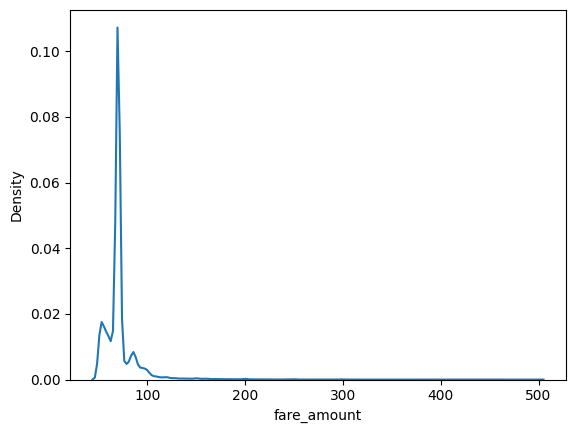

In [23]:
sns.kdeplot(large['fare_amount'])

### Using quantiles to find the outliers.

In [24]:

fare = dtcl['fare_amount']

l = fare.quantile(0.001)
u = fare.quantile(0.999)

print(f'0.1%: {l}, 99.9%: {u}')

0.1%: 3.0, 99.9%: 142.3


* 99.9% of the rides have fare ≤ 142.3
* Only 0.1% of rides are above 142.3
* 99.9% of rides have fare ≥ 3.0
* Only 0.1% of rides are below 3.0

In [25]:
# filter out the outlier fares
# 3 is base fare rate

dtcl = dtcl[(dtcl['fare_amount']<=142.3) & (dtcl['fare_amount']>=3)]

In [26]:
dtcl

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,229,237,1,10.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,236,237,1,5.1
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,141,141,1,5.1
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,244,244,2,7.2
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,244,116,2,5.8
...,...,...,...,...,...,...,...,...,...,...
2935072,1,2025-01-31 23:01:14,2025-01-31 23:08:49,1.0,1.50,1.0,163,48,2,8.6
2935073,1,2025-01-31 23:11:28,2025-01-31 23:14:45,1.0,0.60,1.0,48,48,2,5.1
2935074,2,2025-01-31 23:14:32,2025-01-31 23:28:02,1.0,1.96,1.0,142,164,1,14.2
2935075,2,2025-01-31 23:15:51,2025-01-31 23:21:22,2.0,0.89,1.0,230,142,1,7.2


### check per mile fare.

In [27]:
permile = dtcl['fare_amount'] / (dtcl['trip_distance']+np.finfo(float).eps) 

# epsilon value added to prevent diving by 0. some trip_distances are 0

In [28]:
dtcl[(dtcl['fare_amount']/(dtcl['trip_distance']+np.finfo(float).eps))>20]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount
70,2,2025-01-01 00:55:23,2025-01-01 00:57:26,1.0,0.20,1.0,140,140,1,4.40
92,1,2025-01-01 00:49:48,2025-01-01 00:49:48,1.0,0.00,1.0,87,264,2,20.06
204,2,2025-01-01 00:37:43,2025-01-01 00:37:53,1.0,0.00,5.0,148,148,1,12.00
352,2,2025-01-01 00:10:02,2025-01-01 00:25:46,2.0,0.64,1.0,229,161,1,13.50
358,2,2025-01-01 00:57:08,2025-01-01 00:57:16,3.0,0.00,5.0,141,141,1,30.00
...,...,...,...,...,...,...,...,...,...,...
2934938,2,2025-01-31 23:57:09,2025-01-31 23:57:19,1.0,0.00,2.0,138,138,4,70.00
2934961,2,2025-01-31 23:41:22,2025-01-31 23:43:05,1.0,0.04,1.0,263,263,3,3.70
2935007,2,2025-01-31 23:10:12,2025-01-31 23:10:40,1.0,0.00,1.0,132,132,4,3.00
2935029,2,2025-01-31 23:32:02,2025-01-31 23:32:36,1.0,0.08,2.0,114,114,2,70.00


In [29]:
permile.describe()

count    2.834573e+06
mean     1.378312e+15
std      1.930013e+16
min      8.782663e-04
25%      5.819672e+00
50%      7.288136e+00
75%      9.224138e+00
max      6.395111e+17
dtype: float64

In [30]:
dt[(dt['total_amount']/(dt['trip_distance']+np.finfo(float).eps))>20]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.10,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.00
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.10,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.00
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.40,1.0,N,170,170,1,4.40,3.5,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.00
11,2,2025-01-01 00:33:58,2025-01-01 00:37:23,1.0,0.56,1.0,N,263,236,1,5.80,1.0,0.5,2.16,0.0,1.0,12.96,2.5,0.0,0.00
21,2,2025-01-01 00:34:40,2025-01-01 00:51:19,2.0,1.19,1.0,N,246,170,1,14.90,1.0,0.5,3.98,0.0,1.0,23.88,2.5,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3475097,1,2025-01-31 23:30:42,2025-01-31 23:31:06,NaN,0.00,NaN,None,79,79,0,6.75,0.0,0.5,0.00,0.0,1.0,11.50,NaN,NaN,0.75
3475140,1,2025-01-31 23:59:03,2025-02-01 00:03:11,NaN,0.40,NaN,None,144,211,0,6.55,0.0,0.5,0.00,0.0,1.0,11.30,NaN,NaN,0.75
3475144,2,2025-01-31 23:44:00,2025-01-31 23:44:00,NaN,0.00,NaN,None,137,137,0,13.80,0.0,0.5,0.00,0.0,1.0,18.55,NaN,NaN,0.75
3475157,1,2025-01-31 23:10:25,2025-01-31 23:36:21,NaN,0.00,NaN,None,144,263,0,22.25,2.0,0.5,4.60,0.0,1.0,35.60,NaN,NaN,0.75


* filtering outliers and cleaning based on per mile fare ration offers much robust method than looking at fare amount and distance seperately.
* need to decide on a threhold that would give us theorectical maximun possible fare rate per mile based on NYC taxi fare rules.

### Theoretical maximum rate per mile if distance covered is 0.5

In [31]:
BASE_FARE        = 3.00   # fixed at meter start
RATE_PER_MILE    = 3.50   # $0.70 per 1/5 mile = $3.50/mile moving
TIME_RATE        = 0.70   # per 60 seconds stopped or slow traffic
RUSH_SURCHARGE   = 2.50   # weekdays 4–8pm (excluding holidays)
NIGHT_SURCHARGE  = 1.00   # 8pm–6am (updated rule)
CONGESTION       = 2.50   # Manhattan south of 96th St for yellow taxi
MTA_SURCHARGE    = 0.50
IMPROVEMENT      = 1.00
MTA_CONGESTION_TOLL = 0.75

# Worst case: 0.5 mile trip, fully stopped 50% of the time
# At city speeds (~10mph), 0.5 miles takes ~3 minutes
# Half stopped = 1.5 min of time charges

TIME_CHARGES = (90/60) * TIME_RATE # 3MIN=90 secs, per 60 sec charge

DISTANCE = 0.5

max_fare = (BASE_FARE 
            +(RATE_PER_MILE*DISTANCE)
            +TIME_CHARGES
            +RUSH_SURCHARGE
            +NIGHT_SURCHARGE
            +CONGESTION
            +MTA_SURCHARGE
            +IMPROVEMENT
            +MTA_CONGESTION_TOLL)

max_fare_per_mile = max_fare / DISTANCE

print(f"Theoretical max fare for a 0.5 mile trip: {max_fare}")
print(f"Theoretical max fare per mile for a 0.5 mile trip: {max_fare_per_mile}")

Theoretical max fare for a 0.5 mile trip: 14.05
Theoretical max fare per mile for a 0.5 mile trip: 28.1
